# Supermarket Sales — Basic EDA

This notebook looks at how sales change across branches, product lines, customer groups and hours of the day. I kept the analysis focused on the questions in the task, with a few extra checks where they add useful business context.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Use the CSV beside the notebook when available.
csv_path = Path("supermarket_sales - Sheet1.csv")

if not csv_path.exists():
    csv_path = Path("/mnt/data/supermarket_sales - Sheet1.csv")

df = pd.read_csv(csv_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 1,000
Columns: 17


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


## Quick data check

Before doing any grouping, I checked column types, missing values and duplicate rows. This is enough to catch the most common issues that could affect the summaries later.

In [12]:
quality_check = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique_values": df.nunique()
})

print("Duplicate rows:", df.duplicated().sum())
quality_check

Duplicate rows: 0


,dtype,missing,unique_values
Invoice ID,str,0,1000
Branch,str,0,3
City,str,0,3
Customer type,str,0,2
Gender,str,0,2
Product line,str,0,6
Unit price,float64,0,943
Quantity,int64,0,10
Tax 5%,float64,0,990
Total,float64,0,990


## Preparing the date and time fields

Date and Time arrived as text. I converted them first, then created hour and month fields so the time-based comparisons are easier to build.

In [13]:
df["Date"] = pd.to_datetime(df["Date"])
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M").dt.time

df["Hour"] = pd.to_datetime(df["Time"].astype(str), format="%H:%M:%S").dt.hour

df["Month"] = df["Date"].dt.month_name()

print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Hours covered:", df["Hour"].min(), "to", df["Hour"].max())

Date range: 2019-01-01 to 2019-03-30
Hours covered: 10 to 20


## Sales summaries by category

Here I compared revenue and order count across the four categorical dimensions required in the task. Keeping both measures is useful because more orders do not always mean more revenue.

In [14]:
def sales_summary(column):
    return (
        df.groupby(column)
          .agg(total_sales=("Total", "sum"), order_count=("Invoice ID", "nunique"))
          .sort_values("total_sales", ascending=False)
          .round({"total_sales": 2})
    )

branch_summary = sales_summary("Branch")
product_summary = sales_summary("Product line")
customer_summary = sales_summary("Customer type")
gender_summary = sales_summary("Gender")

print("SALES BY BRANCH")
display(branch_summary)

print("\nSALES BY PRODUCT LINE")
display(product_summary)

print("\nSALES BY CUSTOMER TYPE")
display(customer_summary)

print("\nSALES BY GENDER")
display(gender_summary)

SALES BY BRANCH


,total_sales,order_count
Branch,,
C,110568.71,328
A,106200.37,340
B,106197.67,332



SALES BY PRODUCT LINE


,total_sales,order_count
Product line,,
Food and beverages,56144.84,174
Sports and travel,55122.83,166
Electronic accessories,54337.53,170
Fashion accessories,54305.90,178
Home and lifestyle,53861.91,160
Health and beauty,49193.74,152



SALES BY CUSTOMER TYPE


,total_sales,order_count
Customer type,,
Member,164223.44,501
Normal,158743.30,499



SALES BY GENDER


,total_sales,order_count
Gender,,
Female,167882.92,501
Male,155083.82,499


## Leaders, weaker categories and busy hours

I pulled out the top and bottom product lines, the busiest hour by number of orders, and the monthly revenue totals. This gives a compact view of where the strongest activity sits.

In [15]:
hourly = (df.groupby("Hour").agg(total_sales=("Total", "sum"), order_count=("Invoice ID", "nunique")).sort_index())

monthly_sales = (df.groupby("Month")["Total"].sum().sort_values(ascending=False))

top_product = product_summary.index[0]
bottom_product = product_summary.index[-1]
busiest_hour = hourly["order_count"].idxmax()

print(
    f"Top product line: {top_product} "
    f"(${product_summary.loc[top_product, 'total_sales']:,.2f})"
)
print(
    f"Bottom product line: {bottom_product} "
    f"(${product_summary.loc[bottom_product, 'total_sales']:,.2f})"
)
print(
    f"Busiest hour: {busiest_hour}:00 "
    f"({int(hourly.loc[busiest_hour, 'order_count'])} orders)"
)
print("\nMonthly sales:")
display(monthly_sales.to_frame("total_sales").round(2))

Top product line: Food and beverages ($56,144.84)
Bottom product line: Health and beauty ($49,193.74)
Busiest hour: 19:00 (113 orders)

Monthly sales:


,total_sales
Month,
January,116291.87
March,109455.51
February,97219.37


## Revenue by product line

The first chart ranks product lines by total revenue. A horizontal layout makes the differences easier to compare without squeezing the category names.

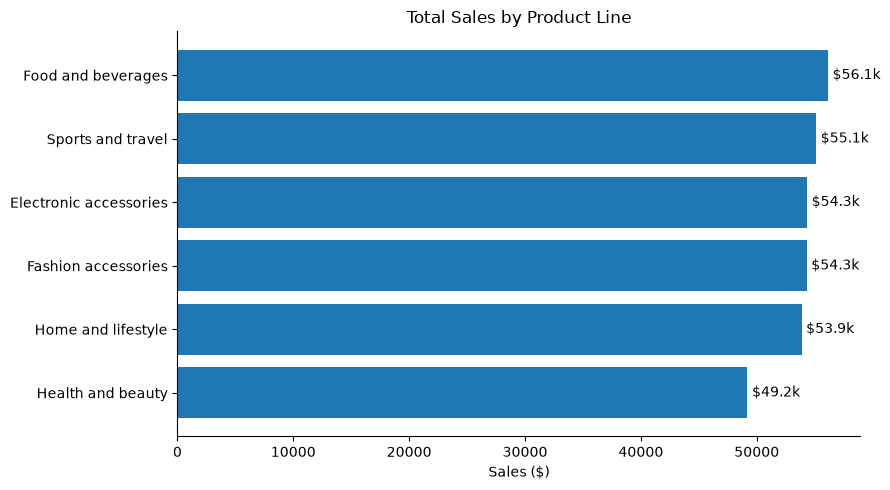

In [16]:
product_plot = product_summary.sort_values("total_sales")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    product_plot.index,
    product_plot["total_sales"]
)

ax.set_title("Total Sales by Product Line")
ax.set_xlabel("Sales ($)")
ax.set_ylabel("")

for bar in bars:
    value = bar.get_width()
    ax.text(
        value + 400,
        bar.get_y() + bar.get_height() / 2,
        f"${value/1000:.1f}k",
        va="center"
    )

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Customer mix

Members and normal customers are almost evenly split, so I used a donut chart here to show how balanced the order mix actually is rather than forcing another bar chart.

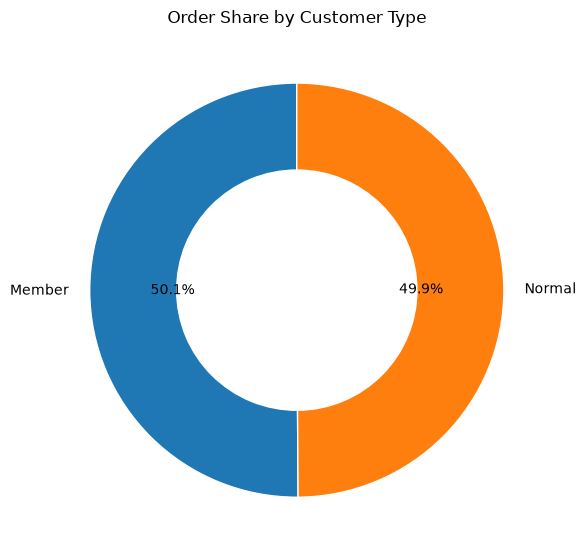

In [17]:
customer_orders = (df["Customer type"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    customer_orders,
    labels=customer_orders.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.42, "edgecolor": "white"}
)

ax.set_title("Order Share by Customer Type")
plt.tight_layout()
plt.show()

## Sales through the day

Instead of only reporting the busiest hour, this view shows the full daily pattern. The line makes the lunch and evening peaks easy to spot, while the marker calls out the strongest revenue hour.

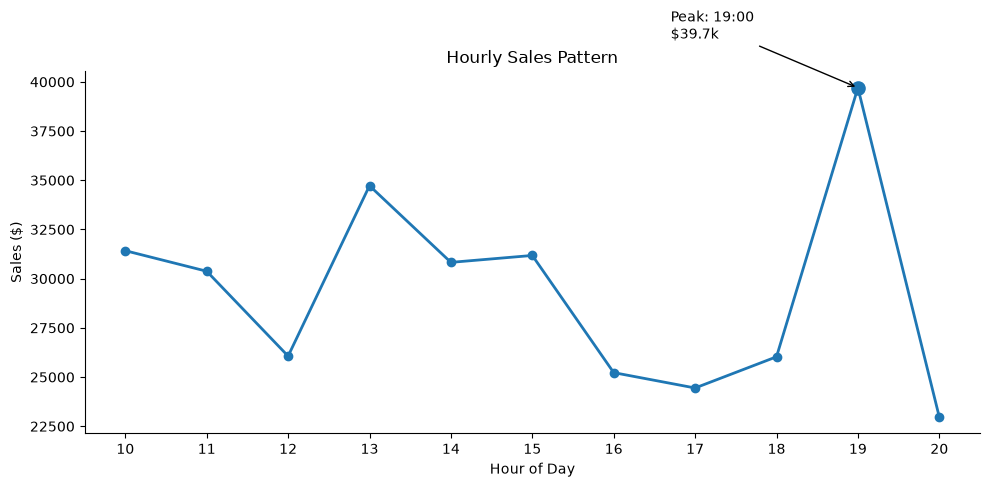

In [18]:
peak_sales_hour = hourly["total_sales"].idxmax()
peak_sales_value = hourly.loc[peak_sales_hour, "total_sales"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    hourly.index,
    hourly["total_sales"],
    marker="o",
    linewidth=2
)

ax.scatter(
    peak_sales_hour,
    peak_sales_value,
    s=90,
    zorder=3
)

ax.annotate(
    f"Peak: {peak_sales_hour}:00\n${peak_sales_value/1000:.1f}k",
    xy=(peak_sales_hour, peak_sales_value),
    xytext=(peak_sales_hour - 2.3, peak_sales_value + 2500),
    arrowprops={"arrowstyle": "->"}
)

ax.set_title("Hourly Sales Pattern")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Sales ($)")
ax.set_xticks(hourly.index)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Branch

The final chart checks whether product performance is consistent across branches or driven by one location.

The heatmap below gives one last check on how each branch contributes to those product-line totals.

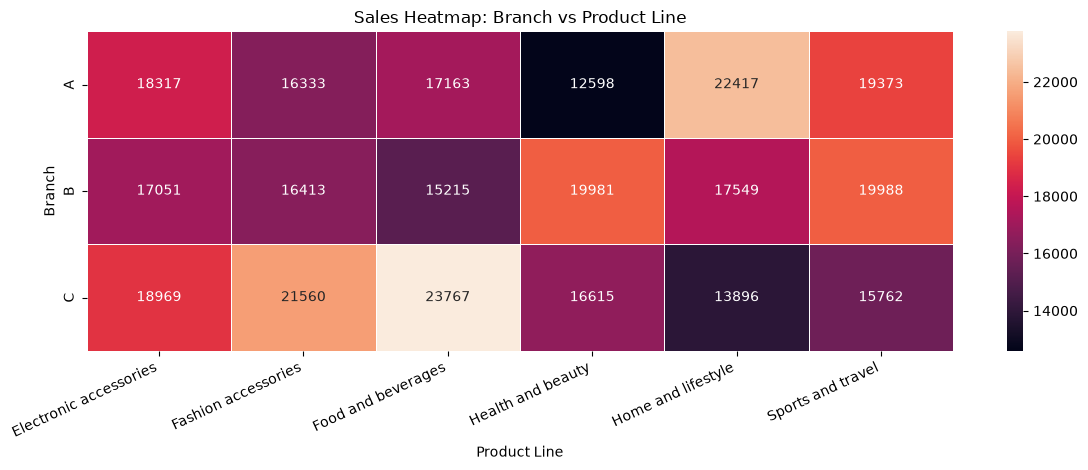

In [19]:
branch_product = pd.pivot_table(
    df,
    index="Branch",
    columns="Product line",
    values="Total",
    aggfunc="sum"
)

fig, ax = plt.subplots(figsize=(12, 4.8))

sns.heatmap(
    branch_product,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Sales Heatmap: Branch vs Product Line")
ax.set_xlabel("Product Line")
ax.set_ylabel("Branch")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()